In [18]:
import pandas as pd

fitxer = "D:/DDAA/SimuladorEmpresarial/RRHH_130925_Barreras.xlsx"
df_servicios = pd.read_excel(fitxer, sheet_name=1)  # segona pestanya (índex 1)


# Converteix comes decimals a punts i passa a float
columnes_num = ['Nada', 'Poco', 'Bastante', 'Mucho']

for col in columnes_num:
    df_servicios[col] = (
        df_servicios[col]
        .astype(str)          # assegurem que és string
        .str.replace(',', '.', regex=False)  # substituïm coma per punt
        .astype(float)        # convertim a número
    )


# Passem a long format
df_servicios_long = df_servicios.melt(
    id_vars=['Year', 'Barrera'],       # columnes que no es desfan
    value_vars=columnes_num,         # columnes que s’apilen
    var_name='Categoría',
    value_name='Porcentaje'
)

# Li canviem el nom
df_servicios_long = df_servicios_long.rename(columns={'Year': 'Año'})

df_servicios_long.head(10)



,Año,Barrera,Categoría,Porcentaje
0,2019,El nivel de formación de los empleados era el ...,Nada,13.179
1,2019,La estrategia preferida de la empresa fue cont...,Nada,24.645
2,2019,Dificultad para evaluar la necesidades de form...,Nada,30.468
3,2019,La falta de cursos de formación adecuados en e...,Nada,25.501
4,2019,El alto coste de los cursos de formación,Nada,19.927
5,2019,El mayor esfuerzo realizado en años anteriores...,Nada,25.855
6,2019,La elevada carga de trabajo y el escaso tiempo...,Nada,10.804
7,2019,Dificultad para acceder a ayudas o subvencione...,Nada,19.130
8,2020,El nivel de formación de los empleados era el ...,Nada,10.600
9,2020,La estrategia preferida de la empresa fue cont...,Nada,34.300


C:\Users\gemma\AppData\Local\Temp\ipykernel_15164\3853467173.py:54: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  left[i] + width / 2, bar.get_y() + bar.get_height() / 2,


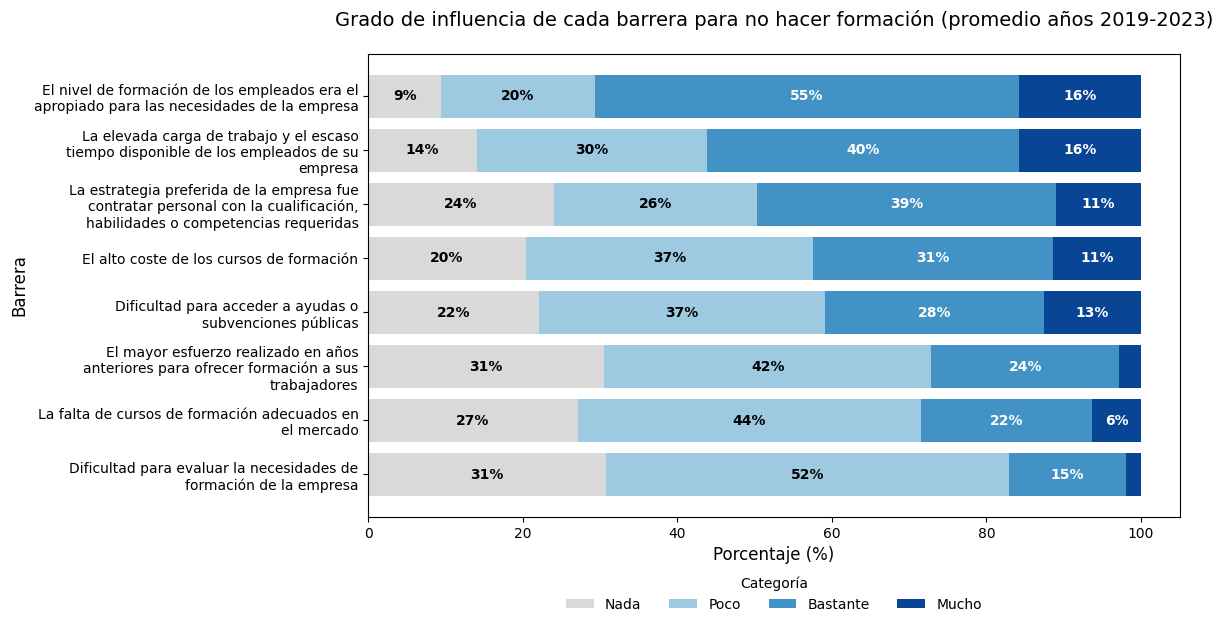

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import textwrap

# 🎨 Colors per categoria (de gris → blau fosc)
colors = {
    'Nada': '#d9d9d9',
    'Poco': '#9ecae1',
    'Bastante': '#4292c6',
    'Mucho': '#084594'
}
cats = ['Nada', 'Poco', 'Bastante', 'Mucho']

# 🧠 1️⃣ Calculem la mitjana per cada Barrera i Categoria
df_resumen = (
    df_servicios_long
    .groupby(['Barrera', 'Categoría'], as_index=False)['Porcentaje']
    .mean()
)

# Assegurem ordre de categories
df_resumen['Categoría'] = pd.Categorical(df_resumen['Categoría'], categories=cats, ordered=True)

# 📊 2️⃣ Pivotem la taula (una fila per Barrera)
df_pivot = df_resumen.pivot(index='Barrera', columns='Categoría', values='Porcentaje').fillna(0)
df_pivot = df_pivot[cats]

# 🧮 3️⃣ Ordenem les barreres segons el % de 'Bastante' (descendent)
df_pivot = df_pivot.sort_values(by='Bastante', ascending=True)

# 🪶 4️⃣ Partim les etiquetes llargues automàticament
df_pivot.index = [
    '\n'.join(textwrap.wrap(barrera, width=45))  # ajusta 'width' segons la llargada desitjada
    for barrera in df_pivot.index
]

# 📐 5️⃣ Mida del gràfic adaptada al nombre de barreres
fig_width = 12
fig_height = max(6, len(df_pivot) * 0.8)

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

# 🧱 6️⃣ Dibuixem les barres apilades
left = np.zeros(len(df_pivot))
for cat in cats:
    bars = ax.barh(df_pivot.index, df_pivot[cat], left=left, color=colors[cat], label=cat)

    # 🏷️ Anotem el percentatge dins del segment (si el segment és prou gran)
    for i, bar in enumerate(bars):
        width = bar.get_width()
        if width > 5:
            ax.text(
                left[i] + width / 2, bar.get_y() + bar.get_height() / 2,
                f"{width:.0f}%", ha='center', va='center',
                color='white' if cat in ['Bastante', 'Mucho'] else 'black',
                fontsize=10, fontweight='bold'
            )
    left += df_pivot[cat]

# 🏷️ 7️⃣ Estètica general
ax.set_xlabel("Porcentaje (%)", fontsize=12)
ax.set_ylabel("Barrera", fontsize=12)
ax.set_title("Grado de influencia de cada barrera para no hacer formación (promedio años 2019-2023)", fontsize=14, pad=20)
ax.legend(title="Categoría", bbox_to_anchor=(0.5, -0.1), loc='upper center', ncol=4, frameon=False)

plt.tight_layout()
plt.show()



In [20]:
""" import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Definició de paleta personalitzada
## De gris clar ("Nada") → blau fosc ("Mucho")
categories = ['Nada', 'Poco', 'Bastante', 'Mucho']
colors = plt.cm.Blues([0.3, 0.5, 0.7, 0.9])  # intensitat creixent
color_map = dict(zip(categories, colors))


# Gràfic d’àrea apilada per motiu
# ----------------------------
barrera = 'El nivel de formación de los empleados era el apropiado para las necesidades de la empresa'  # canvia segons vulguis

df_motiu = df_servicios_long[df_servicios_long['Barrera'] == barrera]
df_motiu = df_motiu.pivot(index='Año', columns='Categoría', values='Porcentaje')[categories]

df_motiu.plot(kind='area', stacked=True, figsize=(8,5), color=[color_map[c] for c in categories])
plt.title(f"Evolució de les respostes per al motiu: {barrera}", fontsize=12)
plt.ylabel("Porcentaje (%)")
plt.xlabel("Año")
plt.legend(title="Categoría", loc='upper left')
plt.grid(alpha=0.3) 
plt.tight_layout()
plt.show()"""

' import matplotlib.pyplot as plt\nimport matplotlib.colors as mcolors\n\n# Definició de paleta personalitzada\n## De gris clar ("Nada") → blau fosc ("Mucho")\ncategories = [\'Nada\', \'Poco\', \'Bastante\', \'Mucho\']\ncolors = plt.cm.Blues([0.3, 0.5, 0.7, 0.9])  # intensitat creixent\ncolor_map = dict(zip(categories, colors))\n\n\n# Gràfic d’àrea apilada per motiu\n# ----------------------------\nbarrera = \'El nivel de formación de los empleados era el apropiado para las necesidades de la empresa\'  # canvia segons vulguis\n\ndf_motiu = df_servicios_long[df_servicios_long[\'Barrera\'] == barrera]\ndf_motiu = df_motiu.pivot(index=\'Año\', columns=\'Categoría\', values=\'Porcentaje\')[categories]\n\ndf_motiu.plot(kind=\'area\', stacked=True, figsize=(8,5), color=[color_map[c] for c in categories])\nplt.title(f"Evolució de les respostes per al motiu: {barrera}", fontsize=12)\nplt.ylabel("Porcentaje (%)")\nplt.xlabel("Año")\nplt.legend(title="Categoría", loc=\'upper left\')\nplt.grid(al

C:\Users\gemma\AppData\Local\Temp\ipykernel_15164\3433980734.py:41: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


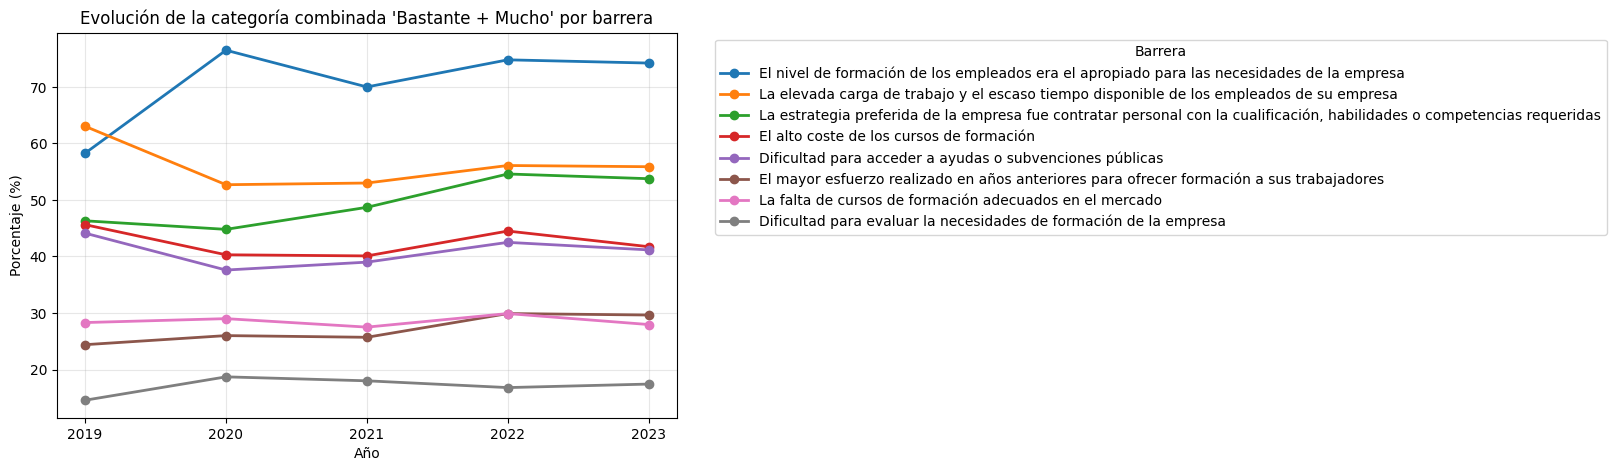

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1️⃣ Filtrarem només les categories 'Bastante' i 'Mucho'
df_bm = df_servicios_long[df_servicios_long['Categoría'].isin(['Bastante', 'Mucho'])]

# 2️⃣ Agrupem per Barrera i Any i sumem els percentatges
df_bm_sum = (
    df_bm.groupby(['Barrera', 'Año'], as_index=False)['Porcentaje']
    .sum()
    .rename(columns={'Porcentaje': 'Porcentaje_Bastante_Mucho'})
)

# 3️⃣ Obtenim l'ordre de les barreres segons el % més alt l'any 2023
ordre_barreres = (
    df_bm_sum[df_bm_sum['Año'] == 2023]
    .sort_values('Porcentaje_Bastante_Mucho', ascending=False)['Barrera']
    .tolist()
)

# 4️⃣ Gràfic de línies
plt.figure(figsize=(8, 5))

for motiu in ordre_barreres:
    subset = df_bm_sum[df_bm_sum['Barrera'] == motiu]
    plt.plot(subset['Año'], subset['Porcentaje_Bastante_Mucho'], marker='o', label=motiu, linewidth=2)

plt.title("Evolución de la categoría combinada 'Bastante + Mucho' por barrera", fontsize=12)
plt.ylabel("Porcentaje (%)")
plt.xlabel("Año")
plt.legend(title="Barrera", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)

# 🔧 Forcem només anys enters a l'eix X
anys = sorted(df_bm_sum['Año'].unique())
plt.xticks(ticks=anys, labels=[int(a) for a in anys])

plt.tight_layout()
plt.show()


C:\Users\gemma\AppData\Local\Temp\ipykernel_15164\51492143.py:45: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


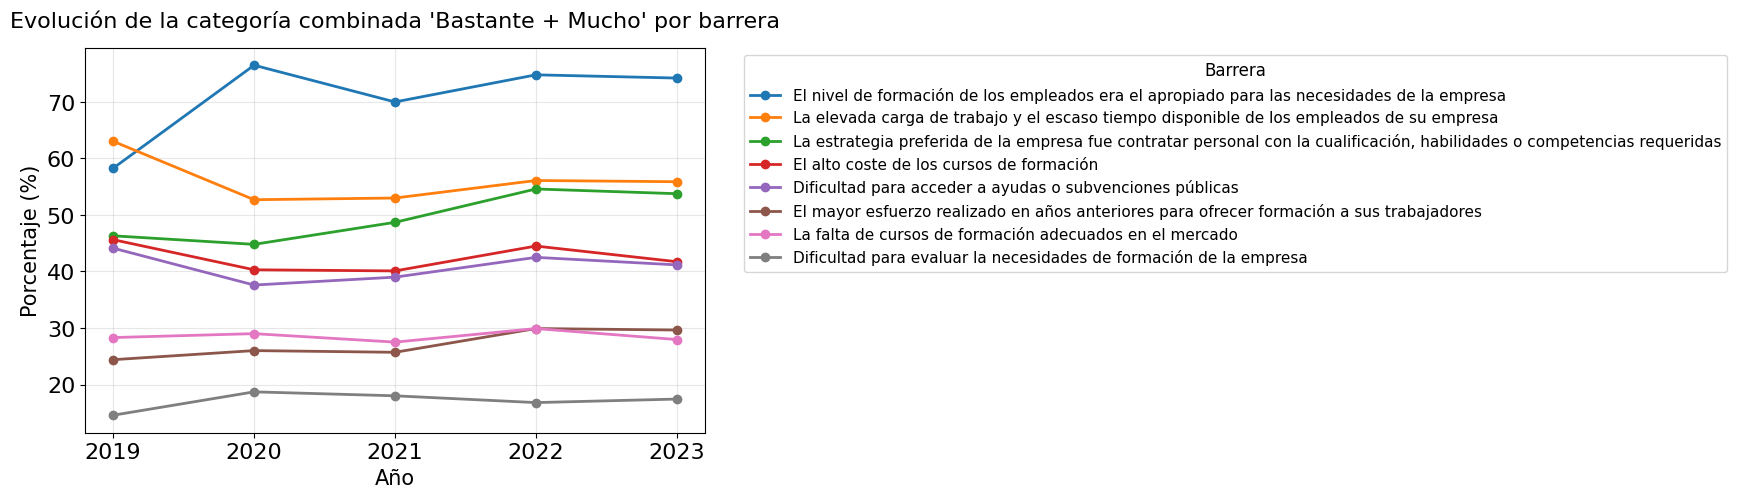

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1️⃣ Filtrarem només les categories 'Bastante' i 'Mucho'
df_bm = df_servicios_long[df_servicios_long['Categoría'].isin(['Bastante', 'Mucho'])]

# 2️⃣ Agrupem per Barrera i Any i sumem els percentatges
df_bm_sum = (
    df_bm.groupby(['Barrera', 'Año'], as_index=False)['Porcentaje']
    .sum()
    .rename(columns={'Porcentaje': 'Porcentaje_Bastante_Mucho'})
)

# 3️⃣ Obtenim l'ordre de les barreres segons el % més alt l'any 2023
ordre_barreres = (
    df_bm_sum[df_bm_sum['Año'] == 2023]
    .sort_values('Porcentaje_Bastante_Mucho', ascending=False)['Barrera']
    .tolist()
)

# 4️⃣ Gràfic de línies
plt.figure(figsize=(8, 5))

for motiu in ordre_barreres:
    subset = df_bm_sum[df_bm_sum['Barrera'] == motiu]
    plt.plot(subset['Año'], subset['Porcentaje_Bastante_Mucho'], marker='o', label=motiu, linewidth=2)

# 🏷️ Estètica amb mides de lletra millorades
plt.title("Evolución de la categoría combinada 'Bastante + Mucho' por barrera", fontsize=16, pad=15)
plt.ylabel("Porcentaje (%)", fontsize=15)
plt.xlabel("Año", fontsize=15)

# ➕ Augmentem la mida dels ticks dels eixos
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.legend(title="Barrera", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11, title_fontsize=12)
plt.grid(alpha=0.3)

# 🔧 Forcem només anys enters a l'eix X
anys = sorted(df_bm_sum['Año'].unique())
plt.xticks(ticks=anys, labels=[int(a) for a in anys], fontsize=16)

plt.tight_layout()
plt.show()


No veiem tendències massa marcades

In [ ]:
df = df_servicios
df['Importancia_Alta'] = df['Bastante'] + df['Mucho']

,Barrera,Year,Nada,Poco,Bastante,Mucho,Importancia_Alta
0,El nivel de formación de los empleados era el ...,2019,13.179,28.546,45.004,13.271,58.275
1,La estrategia preferida de la empresa fue cont...,2019,24.645,29.041,35.761,10.553,46.314
2,Dificultad para evaluar la necesidades de form...,2019,30.468,54.968,12.985,1.579,14.564
3,La falta de cursos de formación adecuados en e...,2019,25.501,46.190,22.068,6.240,28.308
4,El alto coste de los cursos de formación,2019,19.927,34.443,32.569,13.061,45.630
5,El mayor esfuerzo realizado en años anteriores...,2019,25.855,49.753,21.126,3.266,24.392
6,La elevada carga de trabajo y el escaso tiempo...,2019,10.804,26.158,42.043,20.995,63.038
7,Dificultad para acceder a ayudas o subvencione...,2019,19.130,36.743,28.970,15.156,44.126
8,El nivel de formación de los empleados era el ...,2020,10.600,13.000,61.100,15.400,76.500
9,La estrategia preferida de la empresa fue cont...,2020,34.300,20.900,35.700,9.100,44.800


In [ ]:
# =============================================================================
# ANÁLISIS DE TENDENCIAS TEMPORALES
# =============================================================================

def analizar_tendencias_temporales(df):
    """
    Analiza la evolución de las competencias a lo largo del tiempo
    """
    print("\n📈 Analizando tendencias temporales...")
    
    # Crear pivot table para análisis de tendencias
    pivot_tendencias = df.pivot_table(
        index='Barrera', 
        columns='Year', 
        values='Importancia_Alta',
        aggfunc='mean'
    ).reset_index()
    
    # Calcular métricas de crecimiento
    pivot_tendencias['Crecimiento_Absoluto_2019_2023'] = pivot_tendencias[2023] - pivot_tendencias[2019]
    pivot_tendencias['Crecimiento_Relativo_2019_2023'] = (
        (pivot_tendencias[2023] - pivot_tendencias[2019]) / pivot_tendencias[2019] * 100
    ).round(2)
    
    # Identificar tendencias
    pivot_tendencias['Tendencia'] = np.where(
        pivot_tendencias['Crecimiento_Absoluto_2019_2023'] > 5, 'CRECIENTE',
        np.where(pivot_tendencias['Crecimiento_Absoluto_2019_2023'] > 0, 'ESTABLE', 'DECRECIENTE')
    )
    
    return pivot_tendencias

# Ejecutar análisis de tendencias
tendencias = analizar_tendencias_temporales(df)

print("\n🎯 BARRERAS CON MAYOR CRECIMIENTO (2019-2023):")
top_crecimiento = tendencias.nlargest(5, 'Crecimiento_Absoluto_2019_2023')[['Barrera', 'Crecimiento_Absoluto_2019_2023', 'Crecimiento_Relativo_2019_2023', 'Tendencia']]
print(top_crecimiento.to_string(index=False))

print("\n📉 BARRERAS CON MAYOR DECRECIMIENTO (2019-2023):")
top_decrecimiento = tendencias.nsmallest(3, 'Crecimiento_Absoluto_2019_2023')[['Barrera', 'Crecimiento_Absoluto_2019_2023', 'Crecimiento_Relativo_2019_2023', 'Tendencia']]
print(top_decrecimiento.to_string(index=False))


📈 Analizando tendencias temporales...

🎯 BARRERAS CON MAYOR CRECIMIENTO (2019-2023):
                                                                                                                 Barrera  Crecimiento_Absoluto_2019_2023  Crecimiento_Relativo_2019_2023   Tendencia
                              El nivel de formación de los empleados era el apropiado para las necesidades de la empresa                          15.953                           27.38   CRECIENTE
La estrategia preferida de la empresa fue contratar personal con la cualificación, habilidades o competencias requeridas                           7.450                           16.09   CRECIENTE
                                El mayor esfuerzo realizado en años anteriores para ofrecer formación a sus trabajadores                           5.249                           21.52   CRECIENTE
                                                       Dificultad para evaluar la necesidades de formación de la empresa      

In [ ]:
BARRERAS = [
    'El nivel de formación de los empleados era el apropiado para las necesidades de la empresa',
    'La estrategia preferida de la empresa fue contratar personal con la cualificación, habilidades o competencias requeridas', 
    'Dificultad para evaluar la necesidades de formación de la empresa',
    'La falta de cursos de formación adecuados en el mercado',
    'El alto coste de los cursos de formación',
    'El mayor esfuerzo realizado en años anteriores para ofrecer formación a sus trabajadores',
    'La elevada carga de trabajo y el escaso tiempo disponible de los empleados de su empresa',
    'Dificultad para acceder a ayudas o subvenciones públicas'
]

# =============================================================================
# SISTEMA DE PRIORIZACIÓN ESTRATÉGICA - VERSIÓN CORREGIDA
# =============================================================================

def calcular_priorizacion_estrategica(df, tendencias, umbral_alto=0.75, umbral_medio=0.5):
    """
    Calcula prioridades estratégicas basadas en múltiples criterios - CORREGIDO
    """
    print("\n🎯 Calculando priorización estratégica...")
    
    # Obtener datos del año más reciente
    df_ultimo_año = df[df['Year'] == max(df['Year'])].copy()
    
    # CORRECCIÓN 1: Hacer merge explícito con tendencias ANTES de calcular scores
    df_ultimo_año = df_ultimo_año.merge(
        tendencias[['Barrera', 'Crecimiento_Absoluto_2019_2023']], 
        on='Barrera', 
        how='left'
    )
    
    # Calcular score compuesto (50% importancia actual, 30% crecimiento, 20% sector crítico)
    df_ultimo_año['Score_Importancia'] = df_ultimo_año['Importancia_Alta'] / 100
    
    # CORRECCIÓN 2: Score de crecimiento (normalizado) - manejar caso cuando max_crecimiento es 0
    max_crecimiento = abs(df_ultimo_año['Crecimiento_Absoluto_2019_2023']).max()
    if max_crecimiento == 0:
        max_crecimiento = 1  # Evitar división por cero
    
    df_ultimo_año['Score_Crecimiento'] = (
        df_ultimo_año['Crecimiento_Absoluto_2019_2023'] / max_crecimiento
    )
    
    # Score de relevancia sectorial (1.0 para críticas, 0.5 para otras)
    df_ultimo_año['Score_Sector'] = df_ultimo_año['Barrera'].apply(
        lambda x: 1.0 if x in BARRERAS else 0.5
    )
    
    # CORRECCIÓN 3: Manejar valores NaN antes del cálculo final
    df_ultimo_año['Score_Crecimiento'] = df_ultimo_año['Score_Crecimiento'].fillna(0)
    
    # Score final ponderado
    df_ultimo_año['Score_Final'] = (
        df_ultimo_año['Score_Importancia'] * 0.5 +
        df_ultimo_año['Score_Crecimiento'] * 0.3 +
        df_ultimo_año['Score_Sector'] * 0.2
    )
    
    # Clasificar por prioridad
    df_ultimo_año['Prioridad'] = pd.cut(
        df_ultimo_año['Score_Final'],
        bins=[0, umbral_medio, umbral_alto, 1],
        labels=['BAJA', 'MEDIA', 'ALTA'],
        include_lowest=True
    )
    
    return df_ultimo_año.sort_values('Score_Final', ascending=False)

# Calcular priorización
df_priorizacion = calcular_priorizacion_estrategica(df, tendencias)

# Mostrar resultados de priorización
print("\n📊 RESULTADOS DE PRIORIZACIÓN ESTRATÉGICA:")
print("="*100)

for prioridad in ['ALTA', 'MEDIA', 'BAJA']:
    df_prioridad = df_priorizacion[df_priorizacion['Prioridad'] == prioridad]
    
    if prioridad == 'ALTA':
        print(f"\n🔴 LIMITACIONES PREDOMINANTES:")
        print("   " + "="*50)
    elif prioridad == 'MEDIA':
        print(f"\n🟡 LIMITACIONES EXTRA:")
        print("   " + "="*50)
    else:
        print(f"\n🟢 SIN EFECTO:")
        print("   " + "="*50)
    
    for _, row in df_prioridad.iterrows():
        es_critica = "⭐" if row['Barrera'] in BARRERAS else "  "
        print(f"   {es_critica} {row['Barrera']}")
        print(f"      • Score: {row['Score_Final']:.3f} | Importancia: {row['Importancia_Alta']:.1f}% | "
              f"Crecimiento: {row['Crecimiento_Absoluto_2019_2023']:+.1f}%")


🎯 Calculando priorización estratégica...

📊 RESULTADOS DE PRIORIZACIÓN ESTRATÉGICA:

🔴 COMPETENCIAS DE ALTA PRIORIDAD (Inversión estratégica):
   ⭐ El nivel de formación de los empleados era el apropiado para las necesidades de la empresa
      • Score: 0.871 | Importancia: 74.2% | Crecimiento: +16.0%

🟡 COMPETENCIAS DE MEDIA PRIORIDAD (Optimización):
   ⭐ La estrategia preferida de la empresa fue contratar personal con la cualificación, habilidades o competencias requeridas
      • Score: 0.609 | Importancia: 53.8% | Crecimiento: +7.4%

🟢 COMPETENCIAS DE BAJA PRIORIDAD (Mantenimiento):
   ⭐ El mayor esfuerzo realizado en años anteriores para ofrecer formación a sus trabajadores
      • Score: 0.447 | Importancia: 29.6% | Crecimiento: +5.2%
   ⭐ Dificultad para acceder a ayudas o subvenciones públicas
      • Score: 0.350 | Importancia: 41.2% | Crecimiento: -3.0%
   ⭐ La elevada carga de trabajo y el escaso tiempo disponible de los empleados de su empresa
      • Score: 0.345 | Import